# Dataset 1 Analysis: FEIS



In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'eeg_dataset_analysis_lib.py').exists():
            return candidate
    raise RuntimeError('Could not locate project root containing scripts/eeg_dataset_analysis_lib.py')

PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))
from eeg_dataset_analysis_lib import analyze_feis


In [2]:
bundle = analyze_feis()
summary = bundle.summary
assets = bundle.assets
summary['dataset_name'], summary['subject_folder_count']

('FEIS', 23)

## 一、数据集整体概览

In [3]:
overview_df = pd.DataFrame(summary['overview_rows'], columns=['subject', 'trial_count', 'label_count', 'has_full_eeg'])
display(overview_df)
display(Markdown(f"- irregular subjects: `{summary['irregular_subjects']}`"))
display(Markdown(f"- representative subject: `{summary['representative_subject']}`"))
display(Markdown(f"- channels: `{', '.join(summary['channel_names'])}`"))


,subject,trial_count,label_count,has_full_eeg
0,01,160,16,yes
1,02,160,16,yes
2,03,160,16,yes
3,04,160,16,yes
4,05,160,16,yes
5,06,160,16,yes
6,07,160,16,yes
7,08,160,16,yes
8,09,160,16,yes
9,10,160,16,yes


- irregular subjects: `['12', 'chinese-1', 'chinese-2']`

- representative subject: `01`

- channels: `F3, FC5, AF3, F7, T7, P7, O1, O2, P8, T8, F8, AF4, FC6, F4`

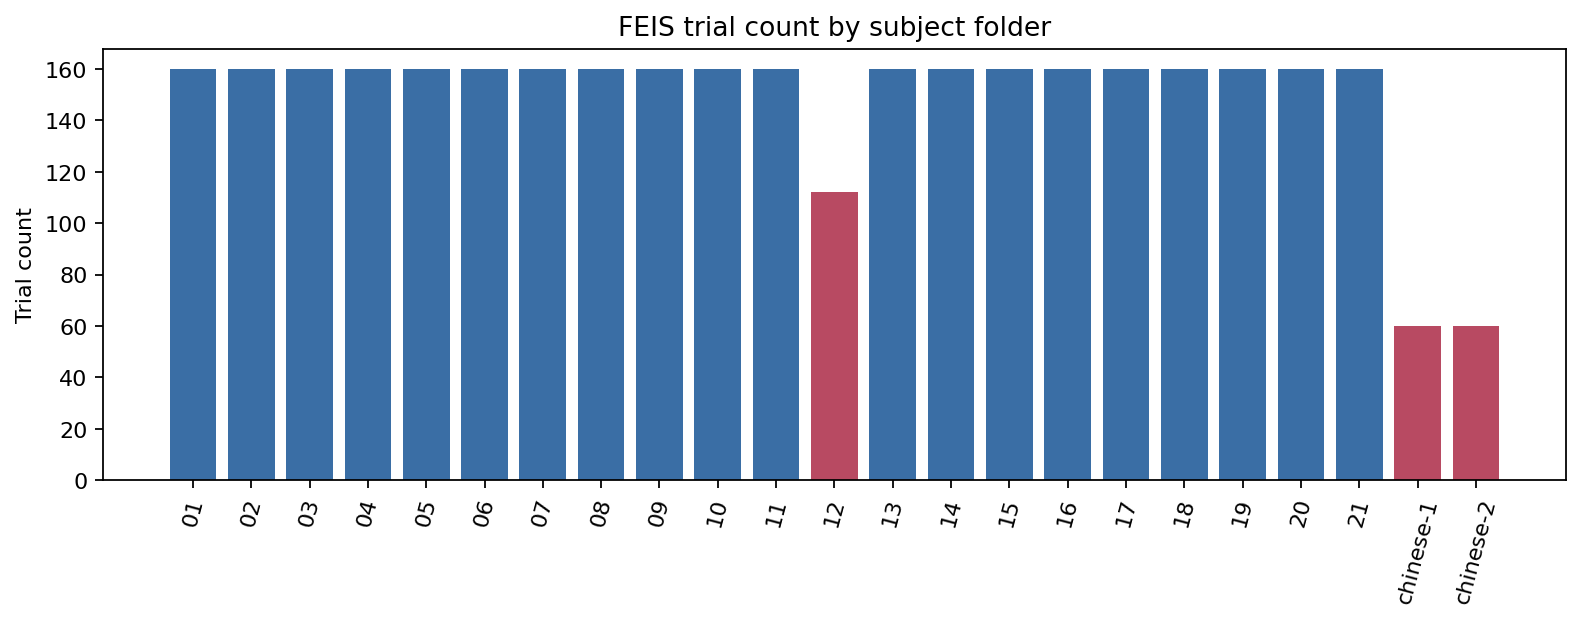

In [4]:
display(Image(filename=assets['trial_counts']))

## 二、实验范式分析

In [7]:
stage_counts_df = pd.DataFrame(list(summary['representative_stage_counts'].items()), columns=['stage', 'samples'])
stage_counts_df['approx_seconds'] = stage_counts_df['samples'] / 256.0
display(stage_counts_df)
display(Markdown('从 `full_eeg.csv` 的 Stage 列可以直接恢复 trial 顺序：`stimuli -> articulators -> thinking -> speaking -> resting`。'))


,stage,samples,approx_seconds
0,articulators,40960,160.0
1,resting,204800,800.0
2,speaking,204800,800.0
3,stimuli,204800,800.0
4,thinking,204800,800.0


从 `full_eeg.csv` 的 Stage 列可以直接恢复 trial 顺序：`stimuli -> articulators -> thinking -> speaking -> resting`。

Resting / resting phase：静息基线。
Stimuli phase：受试看到/听到音素或音节提示，"heard/listening"。
Articulators phase：README 说明这里其实是 1 秒 fixation point。
Thinking phase：受试在脑海中想象说出该音素/音节。
Speaking phase：受试实际说出该音素/音节，同时有录音。

articulators: 40960 点，约 160.0 秒，160 / 160 = 1 秒 / trial
resting: 204800 点，约 800.0 秒，800 / 160 = 5 秒 / trial
speaking: 204800 点，约 800.0 秒，800 / 160 = 5 秒 / trial
stimuli: 204800 点，约 800.0 秒，800 / 160 = 5 秒 / trial
thinking: 204800 点，约 800.0 秒，800 / 160 = 5 秒 / trial

## 三、单受试者深度分析

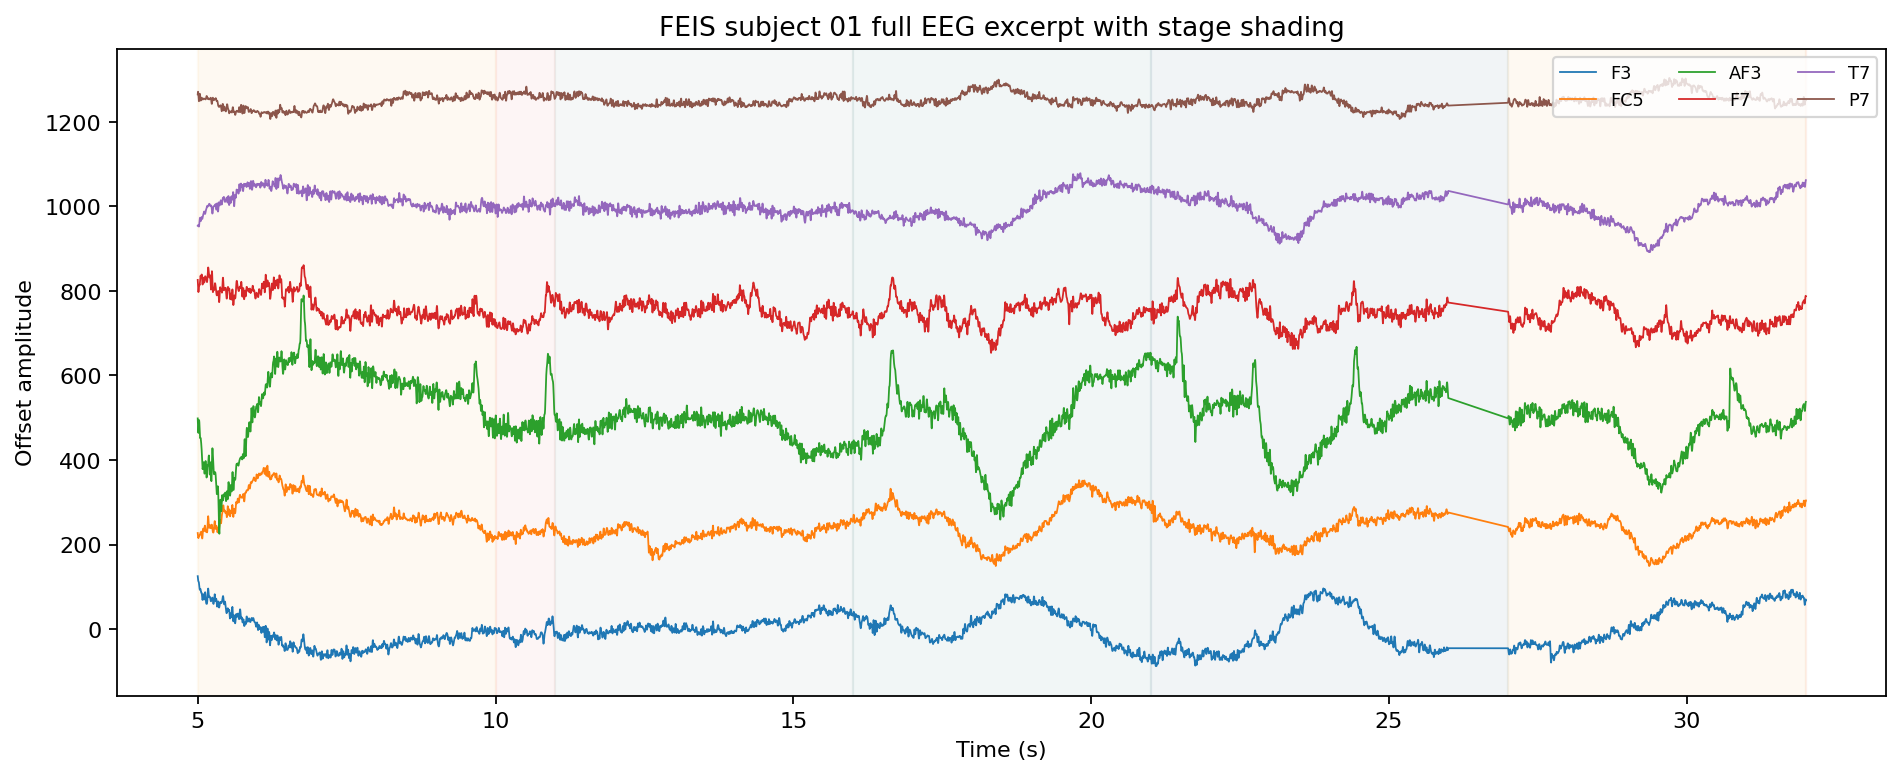

In [8]:
display(Image(filename=assets['waveform']))

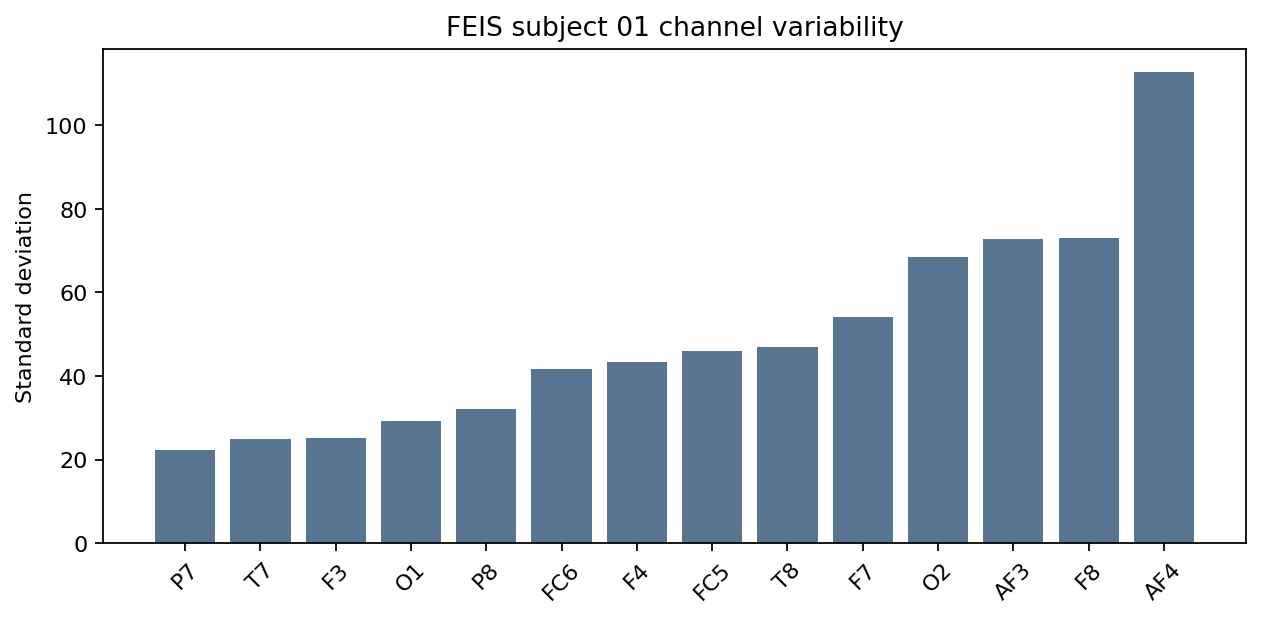

In [9]:
display(Image(filename=assets['channel_std']))

## 四、事件与标签分析

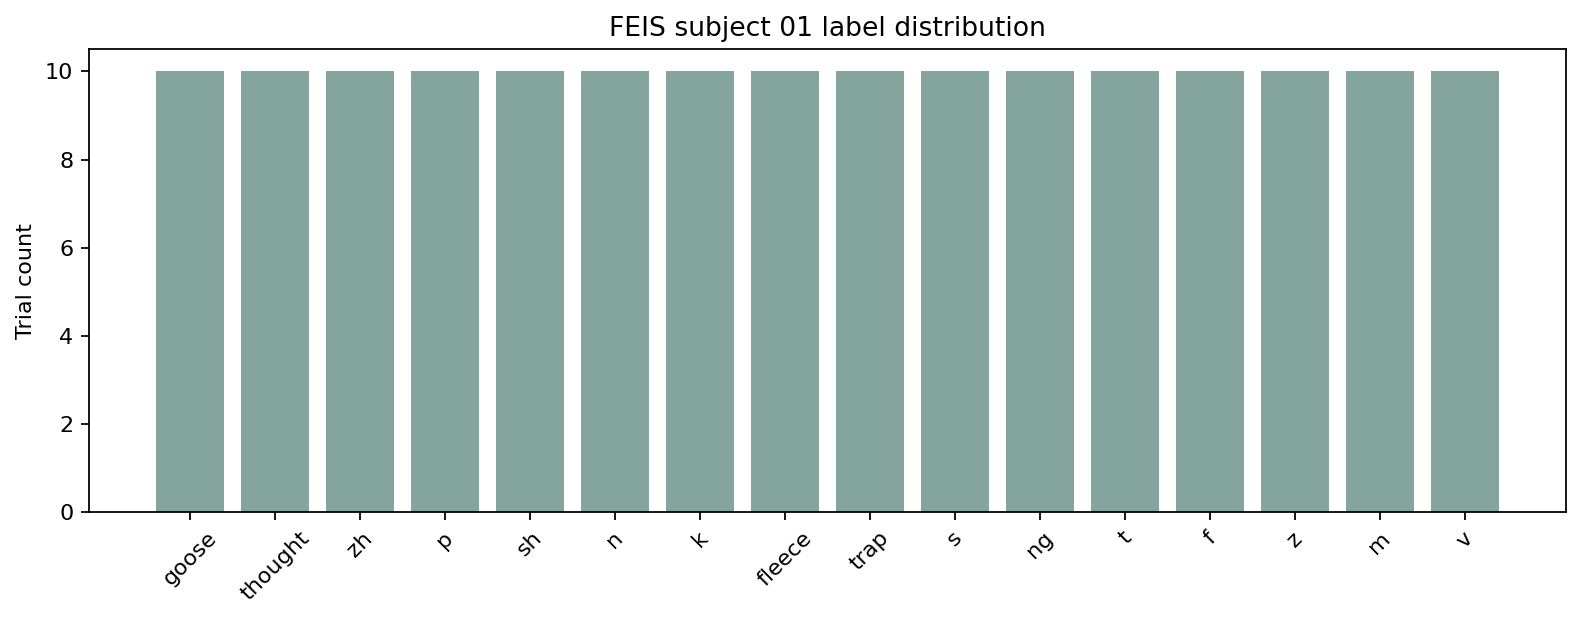

,task,judgment
0,phoneme_classification,Yes - strong fit
1,word_classification,Weak - labels are mostly phoneme/syllable-leve...
2,speech_decoding,Moderate for imagined-vs-spoken/phoneme-level ...
3,speech_reconstruction,Weak foundation only


In [10]:
display(Image(filename=assets['labels']))
fit_df = pd.DataFrame(summary['research_fit'].items(), columns=['task', 'judgment'])
display(fit_df)


## 五、与研究目标的匹配度评估

In [11]:
for note in summary['data_quality_notes']:
    print('-', note)

print('\nKey conclusion: FEIS is a strong pilot set for imagined phoneme classification, but a weak foundation for speech reconstruction.')


- 每个英文被试大多有 160 个 trial，但 subject 12 只有 112 个 trial，是当前下载包里最明显的不规则个体。
- full_eeg.csv 的 Stage / Epoch / Label 列为每个时间点直接给出标签，对齐非常方便。
- 两个 chinese supplementary 文件夹使用了另一套列名（Channel 1-14, Event Id, Event Date, Event Duration），与英文主集 schema 不完全一致。
- 当前发布的是派生 CSV，而不是带 trigger 的原始 EEG 流；重新做更细粒度事件切分的自由度有限。

Key conclusion: FEIS is a strong pilot set for imagined phoneme classification, but a weak foundation for speech reconstruction.


## 六、处理后数据分析

In [12]:
import numpy as np

path = "/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/data/processed/thinking_waveform_pairs/feis/subjects/01.npz"
data = np.load(path, allow_pickle=True)

print(data.files)

['trial_indices', 'labels', 'audio_relpaths', 'channel_names', 'eeg_sfreq_hz', 'stage_names', 'stage__stimuli', 'stage__stimuli__valid_lengths', 'stage__articulators', 'stage__articulators__valid_lengths', 'stage__thinking', 'stage__thinking__valid_lengths', 'stage__speaking', 'stage__speaking__valid_lengths', 'stage__resting', 'stage__resting__valid_lengths']


In [13]:
thinking = data["stage__thinking"]
print(thinking.shape)

(160, 14, 1280)


In [14]:
trial0_thinking = data["stage__thinking"][0]
print(trial0_thinking.shape)

(14, 1280)


这里的14意味着有14个通道，而256HZ对应片段的5s就会有1280个时间点

In [15]:
label0 = data["labels"][0]
audio0 = data["audio_relpaths"][0]

print(label0)
print(audio0)

goose
audio/01/goose.wav


In [16]:
print(data["stage_names"])

['stimuli' 'articulators' 'thinking' 'speaking' 'resting']


In [17]:
trial0_thinking = data["stage__thinking"][0]

print(trial0_thinking)

[[-0.5065612  -0.39029032 -0.42089057 ... -0.0667541  -0.09591158
   0.00427853]
 [ 0.10134254  0.31269374  0.3722694  ...  0.15870443  0.02530111
   0.03927527]
 [ 0.14864242 -0.15697156 -0.40874085 ...  0.39599204  0.26962826
  -0.00341604]
 ...
 [-0.1013431  -0.25865662 -0.3476832  ... -0.07551775 -0.01037514
   0.03346067]
 [ 0.01652913  0.5912239   0.8624129  ...  0.1323002   0.0879713
  -0.05946456]
 [ 0.10357937  0.456832    0.38529432 ... -0.00392479 -0.05077178
  -0.06377743]]


In [18]:
print(trial0_thinking[:3, :10])

[[-0.5065612  -0.39029032 -0.42089057 -0.62291056 -0.867703   -0.95981133
  -0.7830206  -0.40189293 -0.03856784  0.07213931]
 [ 0.10134254  0.31269374  0.3722694   0.22199368 -0.06807575 -0.34521794
  -0.4686356  -0.39211765 -0.18195431  0.03946875]
 [ 0.14864242 -0.15697156 -0.40874085 -0.5391826  -0.49122348 -0.27203056
   0.0154998   0.20998713  0.18655223 -0.0594729 ]]


In [19]:
import pandas as pd

channels = data["channel_names"]
trial0_thinking = data["stage__thinking"][0]

df = pd.DataFrame(trial0_thinking, index=channels)
print(df.iloc[:5, :10])

            0         1         2         3         4         5         6  \
F3  -0.506561 -0.390290 -0.420891 -0.622911 -0.867703 -0.959811 -0.783021   
FC5  0.101343  0.312694  0.372269  0.221994 -0.068076 -0.345218 -0.468636   
AF3  0.148642 -0.156972 -0.408741 -0.539183 -0.491223 -0.272031  0.015500   
F7  -0.022711  0.627833  1.073183  1.212960  1.101063  0.907677  0.810899   
T7  -0.080767 -0.097780 -0.016516  0.186042  0.439079  0.627818  0.674233   

            7         8         9  
F3  -0.401893 -0.038568  0.072139  
FC5 -0.392118 -0.181954  0.039469  
AF3  0.209987  0.186552 -0.059473  
F7   0.886036  1.068671  1.215086  
T7   0.594179  0.496321  0.523784  


这些数值表示的是：某一个 trial、某一个阶段里的 EEG 信号，在预处理之后，每个通道、每个时间点对应的数值。
这个二维数组，本质上是：
行：EEG 通道
列：时间点
值：该通道在该时刻的预处理后振幅
如果这是 trial0_thinking = data["stage__thinking"][0]，那它表示的就是：第 0 个 trial 的 thinking 阶段 EEG 波形。

更具体一点，这些值为什么会长成这样？因为它们已经不是原始 EEG 了，而是经过了这些处理：
bandpass filter
notch filter
common average reference
用 baseline 做了标准化
所以你现在看到的数值：不是原始电压值也不是直接的微伏单位
更接近一种：去噪后重参考后相对 baseline 标准化后的连续信号值
所以例如：-0.5065612，它的意思不是：“绝对电压是 -0.506 微伏”
而更像是：“这个通道在这个时刻，相对于该 trial baseline，处在一个偏低的位置”
同理：0.8624129
更像是：“这个通道在这个时刻，相对于 baseline，有更高的正向偏移”

In [20]:
df_t = pd.DataFrame(trial0_thinking.T, columns=channels)
print(df_t.head())

         F3       FC5       AF3        F7        T7        P7        O1  \
0 -0.506561  0.101343  0.148642 -0.022711 -0.080767 -0.050602  0.133343   
1 -0.390290  0.312694 -0.156972  0.627833 -0.097780 -0.120361  0.283485   
2 -0.420891  0.372269 -0.408741  1.073183 -0.016516 -0.119269  0.441453   
3 -0.622911  0.221994 -0.539183  1.212960  0.186042 -0.013793  0.607501   
4 -0.867703 -0.068076 -0.491223  1.101063  0.439079  0.176405  0.776635   

         O2        P8        T8        F8       AF4       FC6        F4  
0  0.258556  0.119505  0.144733 -0.222736 -0.101343  0.016529  0.103579  
1  0.251893 -0.020050  0.208149 -0.519737 -0.258657  0.591224  0.456832  
2  0.307508 -0.097436  0.163381 -0.575233 -0.347683  0.862413  0.385294  
3  0.446211 -0.093918 -0.029444 -0.299180 -0.368443  0.707939 -0.211031  
4  0.626445 -0.056488 -0.353058  0.204742 -0.395623  0.279345 -1.010947  


In [27]:
channel0 = trial0_thinking[0]
print(channel0[:128])

[-0.5065612  -0.39029032 -0.42089057 -0.62291056 -0.867703   -0.95981133
 -0.7830206  -0.40189293 -0.03856784  0.07213931 -0.14540535 -0.5377899
 -0.8223595  -0.7980401  -0.5108961  -0.23724343 -0.28222826 -0.7399125
 -1.3993691  -1.8746587  -1.8683151  -1.3791484  -0.7079643  -0.2614572
 -0.29405397 -0.7613049  -1.369806   -1.7704906  -1.7580189  -1.3604023
 -0.793171   -0.3311008  -0.17151295 -0.34300327 -0.6907829  -0.9530851
 -0.9103087  -0.5344392  -0.0332559   0.27189466  0.17644611 -0.23421924
 -0.6209841  -0.6370014  -0.20479992  0.40254351  0.7596109   0.6203096
  0.11592901 -0.34734696 -0.4126247  -0.05477183  0.40720168  0.57253677
  0.27949822 -0.26888663 -0.6616948  -0.5855351  -0.04498189  0.65011406
  1.0961003   1.0412172   0.5081442  -0.2532628  -0.91811246 -1.2411655
 -1.1454223  -0.7285007  -0.20239349  0.20624667  0.3585582   0.26339942
  0.06110438 -0.06212192  0.02275475  0.32955903  0.7698016   1.2105688
  1.5299023   1.6441771   1.5168613   1.1672585   0.6774652

In [28]:
channels = data["channel_names"]
idx = list(channels).index("F3")
print(trial0_thinking[idx, :20])

[-0.5065612  -0.39029032 -0.42089057 -0.62291056 -0.867703   -0.95981133
 -0.7830206  -0.40189293 -0.03856784  0.07213931 -0.14540535 -0.5377899
 -0.8223595  -0.7980401  -0.5108961  -0.23724343 -0.28222826 -0.7399125
 -1.3993691  -1.8746587 ]


Text(0, 0.5, 'Amplitude')

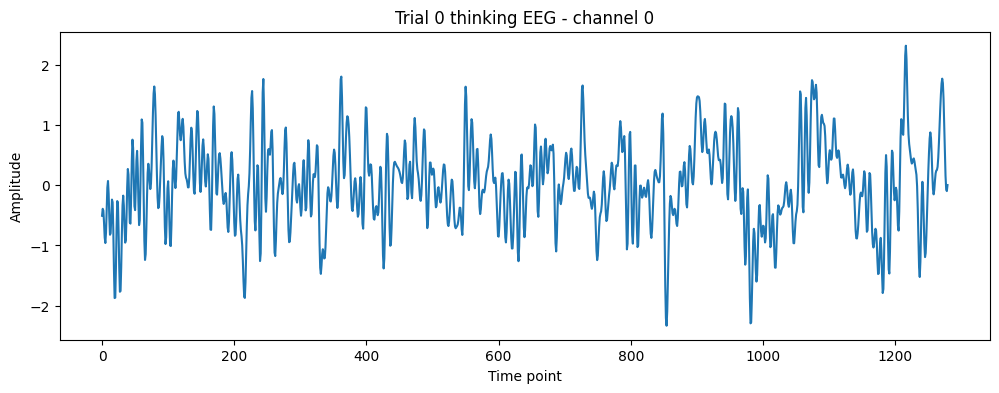

In [31]:
%matplotlib inline

import matplotlib.pyplot as plt

trial0_thinking = data["stage__thinking"][0]

plt.figure(figsize=(12,4))
plt.plot(trial0_thinking[0])
plt.title("Trial 0 thinking EEG - channel 0")
plt.xlabel("Time point")
plt.ylabel("Amplitude")

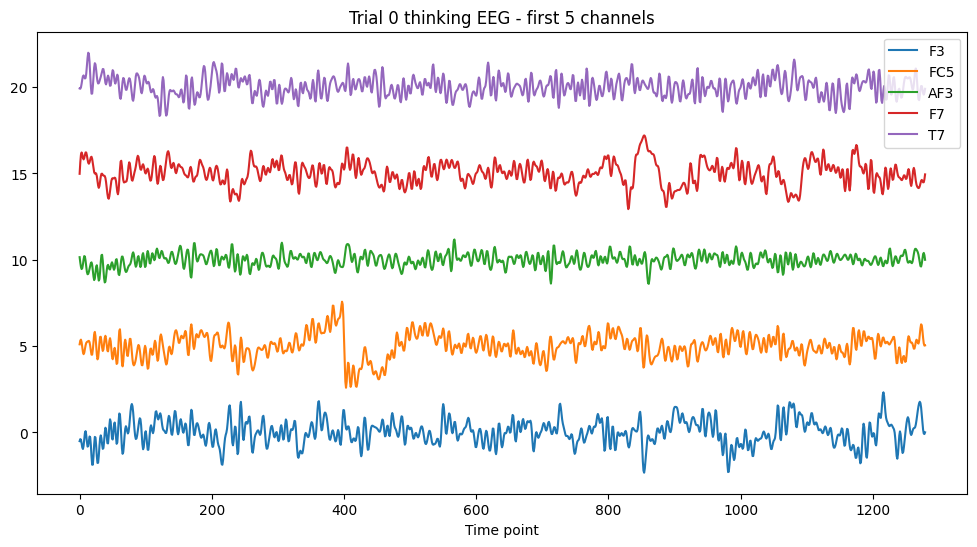

In [34]:
channels = data["channel_names"]
trial0_thinking = data["stage__thinking"][0]

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.plot(trial0_thinking[i] + i * 5, label=channels[i])  # 加偏移防止重叠
plt.legend()
plt.title("Trial 0 thinking EEG - first 5 channels")
plt.xlabel("Time point")
plt.show()

### 7. Test Demo Models‘ Results

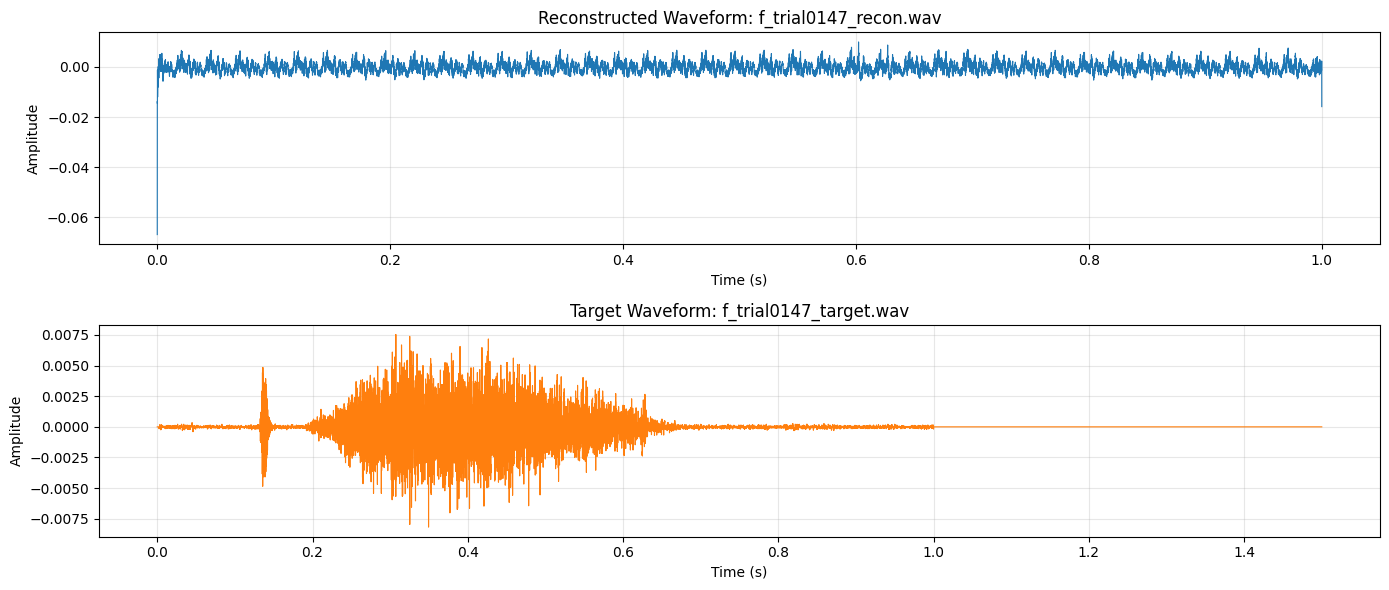

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile

recon_path = Path("/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/eeg2wave_demo_bundle/outputs/recon_wavs/subject_01/f_trial0147_recon.wav")
target_path = Path("/Users/samxie/Research/EEG-Voice/ref_github/speech_decoding/eeg2wave_demo_bundle/outputs/recon_wavs/subject_01/f_trial0147_target.wav")

def load_wav(path: Path):
    sr, audio = wavfile.read(path)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    if np.issubdtype(audio.dtype, np.integer):
        audio = audio.astype(np.float32) / np.iinfo(audio.dtype).max
    else:
        audio = audio.astype(np.float32)
    t = np.arange(len(audio)) / sr
    return sr, t, audio

sr1, t1, recon = load_wav(recon_path)
sr2, t2, target = load_wav(target_path)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

axes[0].plot(t1, recon, linewidth=0.8)
axes[0].set_title(f"Reconstructed Waveform: {recon_path.name}")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].plot(t2, target, linewidth=0.8, color="tab:orange")
axes[1].set_title(f"Target Waveform: {target_path.name}")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()